In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# PRACTICAL DISEASE CLASSIFICATION (TENSORFLOW)
# CORRECTED: NO DATA LEAKAGE + SCHEMA EXPORT
# ==========================================

!pip install -q imbalanced-learn scikit-learn joblib

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import joblib
import os
import json # 🔥 NEW: For schema export
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# 0. Reproducibility
# ------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ------------------------------
# 1. Load Data
# ------------------------------
file_path = "/content/drive/MyDrive/AD_PD_lifestyle/combined_3class.csv"
df = pd.read_csv(file_path)

# ------------------------------
# 2. Define Features
# ------------------------------
target_col = 'DiseaseType'

categorical_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'Hypertension', 'Diabetes', 'Depression'
]

numerical_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'FunctionalAssessment'
]

feature_cols = categorical_cols + numerical_cols

X = df[feature_cols].copy()
y = df[target_col].copy()

# ------------------------------
# 3. STRICT 3-WAY SPLIT (Train/Val/Test)
# ------------------------------
from sklearn.model_selection import train_test_split

# First, pull out 15% as the completely hidden Test Set
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Second, split the remaining 85% into Train and Validation (approx 70/15 overall)
X_train_raw, X_val_raw, y_train_raw, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
)

print("Train shape:", X_train_raw.shape)
print("Val shape  :", X_val_raw.shape)
print("Test shape :", X_test_raw.shape) # The unseen test set

# ------------------------------
# 4. Fit Preprocessor on TRAIN ONLY
# ------------------------------
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_val_processed = preprocessor.transform(X_val_raw)

# 🔥 THE FIX: Transform the unseen raw test set so the baseline models can read it
X_test = preprocessor.transform(X_test_raw)

print("\nProcessed shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed  :", X_val_processed.shape)
print("X_test           :", X_test.shape)

# ------------------------------
# 5. Apply SMOTE ONLY on training data
# ------------------------------
sm = SMOTE(random_state=SEED)
X_train, y_train = sm.fit_resample(X_train_processed, y_train_raw)
X_val = X_val_processed

# ------------------------------
# 6. One-hot encode targets
# ------------------------------
num_classes = len(sorted(y.unique()))
y_train_cat = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes=num_classes)
class_names = [str(c) for c in sorted(y.unique())]

# ------------------------------
# 7. Build Model
# ------------------------------
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(0.3),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(0.25),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_dim = X_train.shape[1]
model = build_model(input_dim, num_classes)

# ------------------------------
# 8. Custom Metrics Callback
# ------------------------------
class SklearnMetricsCallback(callbacks.Callback):
    def __init__(self, train_data, val_data, class_names=None, batch_size=256):
        super().__init__()
        self.X_train, self.y_train = train_data
        self.X_val, self.y_val = val_data
        self.batch_size = batch_size
        self.class_names = class_names
        self.epoch_metrics = []

    def _safe_auc(self, y_true, y_prob):
        try:
            return roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
        except Exception:
            return np.nan

    def _compute_metrics(self, X, y_true):
        y_prob = self.model.predict(X, verbose=0, batch_size=self.batch_size)
        y_pred = np.argmax(y_prob, axis=1)
        metrics_dict = {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
            "auc": self._safe_auc(y_true, y_prob),
            "cm": confusion_matrix(y_true, y_pred),
            "y_pred": y_pred,
            "y_prob": y_prob
        }
        return metrics_dict

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_m = self._compute_metrics(self.X_train, self.y_train)
        val_m = self._compute_metrics(self.X_val, self.y_val)

        self.epoch_metrics.append({
            "epoch": epoch + 1,
            "train_loss": logs.get("loss", np.nan),
            "val_loss": logs.get("val_loss", np.nan),
            "train_acc": train_m["acc"],
            "train_prec": train_m["prec"],
            "train_rec": train_m["rec"],
            "train_f1": train_m["f1"],
            "train_auc": train_m["auc"],
            "val_acc": val_m["acc"],
            "val_prec": val_m["prec"],
            "val_rec": val_m["rec"],
            "val_f1": val_m["f1"],
            "val_auc": val_m["auc"]
        })
        print(f"\nEpoch {epoch+1:03d} | Val F1: {val_m['f1']:.4f}")

# ------------------------------
# 9. Compile & Train Model
# ------------------------------
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

metrics_cb = SklearnMetricsCallback(train_data=(X_train, y_train), val_data=(X_val, y_val), class_names=class_names)
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    metrics_cb
]

print(f"\nStarting TensorFlow Training with {input_dim} features...")
history = model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat), epochs=150, batch_size=64, callbacks=callbacks_list, verbose=1)

# ------------------------------
# 12. Final Evaluation
# ------------------------------
print("\nFinal evaluation on validation set...")
val_probs = model.predict(X_val, verbose=0)
val_preds = np.argmax(val_probs, axis=1)
print(f"✅ Final Validation F1-score : {f1_score(y_val, val_preds, average='weighted', zero_division=0):.4f}")

# ------------------------------
# 13. Save Preprocessor + Model
# ------------------------------
preprocessor_path = "lifestyle_preprocessor.pkl"
joblib.dump(preprocessor, preprocessor_path)

keras_model_path = "disease_model_practical.keras"
model.save(keras_model_path)

# ------------------------------
# 14. Convert to TFLite
# ------------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = "/content/drive/MyDrive/AD_PD_lifestyle/lifestyle.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"✅ Success! Saved TFLite to '{tflite_path}'")

# ------------------------------
# 16. 🔥 THE FIX: EXPORT SCHEMA TO JSON
# ------------------------------
cat_transformer = preprocessor.named_transformers_['cat']
num_transformer = preprocessor.named_transformers_['num']

schema = {
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "means": num_transformer.mean_.tolist(),
    "stds": num_transformer.scale_.tolist(),
    "feature_names_out": list(preprocessor.get_feature_names_out())
}

schema_path = "/content/drive/MyDrive/AD_PD_lifestyle/lifestyle_schema.json"
with open(schema_path, "w") as f:
    json.dump(schema, f)

print(f"✅ EXPORTED STRICT SCHEMA: Saved to '{schema_path}'")

# ------------------------------
# 17. BASELINE COMPARISONS ON TEST SET
# ------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("\n--- BASELINE MODEL COMPARISON (UNSEEN TEST SET) ---")

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train, y_train) # Train on SMOTE data
lr_preds = lr.predict(X_test)
print(f"Logistic Regression -> Acc: {accuracy_score(y_test, lr_preds):.4f} | F1: {f1_score(y_test, lr_preds, average='weighted'):.4f}")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print(f"Random Forest       -> Acc: {accuracy_score(y_test, rf_preds):.4f} | F1: {f1_score(y_test, rf_preds, average='weighted'):.4f}")

# 3. Your Deep Learning Model
dl_probs = model.predict(X_test, verbose=0)
dl_preds = np.argmax(dl_probs, axis=1)
print(f"Proposed Neural Net -> Acc: {accuracy_score(y_test, dl_preds):.4f} | F1: {f1_score(y_test, dl_preds, average='weighted'):.4f}")

Num GPUs Available:  0
Train shape: (2978, 14)
Val shape  : (637, 14)
Test shape : (639, 14)

Processed shapes:
X_train_processed: (2978, 25)
X_val_processed  : (637, 25)
X_test           : (639, 25)

Starting TensorFlow Training with 25 features...
Epoch 1/150
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5029 - loss: 1.0722
Epoch 001 | Val F1: 0.6790
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5901 - loss: 0.9086 - val_accuracy: 0.6939 - val_loss: 0.8135 - learning_rate: 0.0010
Epoch 2/150
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6799 - loss: 0.7183
Epoch 002 | Val F1: 0.7131
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6858 - loss: 0.7117 - val_accuracy: 0.7127 - val_loss: 0.6978 - learning_rate: 0.0010
Epoch 3/150
63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7012 - loss: 0.6635
Epoch 003 | Val F1: 0.7276
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7080 - loss: 0.6517 - val_accuracy: 0.7253 - val_loss: 0.6397 - learning_rate: 0


--- GENERATING SHAP EXPLANATIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Calculating SHAP values (this will take 10-20 seconds)...


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
655/655 ━━━━━

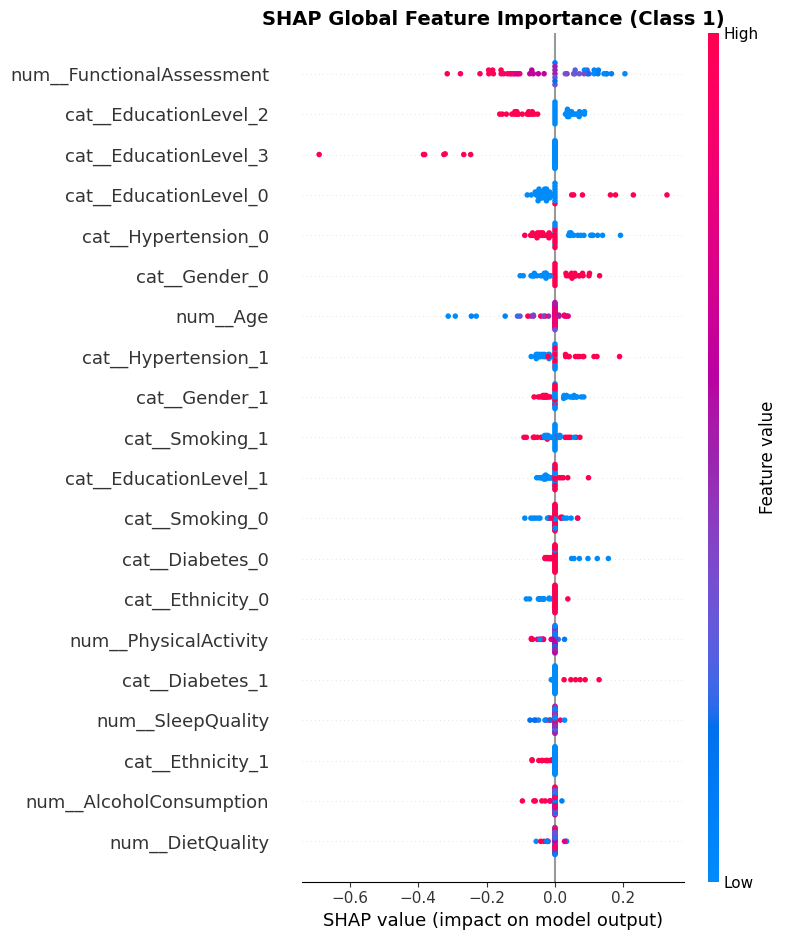

✅ SHAP analysis complete. Graph saved as 'shap_summary_plot.png'


In [ ]:
# ------------------------------
# 18. SHAP EXPLAINABILITY ANALYSIS (FIXED COLUMN NAMES)
# ------------------------------
!pip install -q shap
import shap
import matplotlib.pyplot as plt
import numpy as np

print("\n--- GENERATING SHAP EXPLANATIONS ---")

background = shap.kmeans(X_train, 10)
test_sample = X_test[:50]

explainer = shap.KernelExplainer(model.predict, background)

print("Calculating SHAP values (this will take 10-20 seconds)...")
shap_values = explainer.shap_values(test_sample)

pd_class_index = 1

if isinstance(shap_values, list):
    vals_to_plot = shap_values[pd_class_index]
else:
    if len(shap_values.shape) == 3:
        vals_to_plot = shap_values[:, :, pd_class_index]
    else:
        vals_to_plot = shap_values

print(f"Generating SHAP Summary Plot for Class {pd_class_index}...")
plt.figure(figsize=(10, 6))

# 🔥 THE FIX: Get the exact column names AFTER One-Hot Encoding
processed_feature_names = list(preprocessor.get_feature_names_out())

# Generate the dot plot with the correct names
shap.summary_plot(
    vals_to_plot,
    test_sample,
    feature_names=processed_feature_names, # Use the dynamic names here!
    show=False
)

plt.title(f"SHAP Global Feature Importance (Class {pd_class_index})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP analysis complete. Graph saved as 'shap_summary_plot.png'")


--- LIFESTYLE CALIBRATION ANALYSIS ---
✅ Model loaded successfully from disk!
Brier Score (Parkinson's): 0.1030


<Figure size 800x600 with 0 Axes>

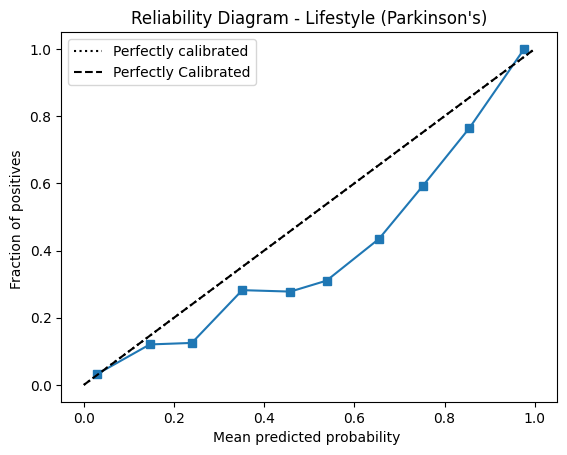

In [ ]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import tensorflow as tf

print("\n--- LIFESTYLE CALIBRATION ANALYSIS ---")

# 1. Reload the saved Keras model to guarantee it is in Colab's memory
try:
    model = tf.keras.models.load_model("disease_model_practical.keras")
    print("✅ Model loaded successfully from disk!")
except Exception as e:
    print("⚠️ Error loading model. Make sure you ran the training cell first so the .keras file exists.")
    raise e

# 2. Get raw probabilities from the Keras model
keras_probs = model.predict(X_test, verbose=0)

# Change this to 1 or 2 depending on your PD class index in 'combined_3class.csv'
TARGET_CLASS = 1
class_name = "Parkinson's"

# 3. Binarize labels: 1 if PD, 0 if anything else
binary_labels = (y_test == TARGET_CLASS).astype(int)
class_probs = keras_probs[:, TARGET_CLASS]

# 4. Calculate Brier Score
brier = brier_score_loss(binary_labels, class_probs)
print(f"Brier Score ({class_name}): {brier:.4f}")

# 5. Plot the Calibration Curve
prob_true, prob_pred = calibration_curve(binary_labels, class_probs, n_bins=10)
disp = CalibrationDisplay(prob_true, prob_pred, binary_labels)

plt.figure(figsize=(8, 6))
disp.plot()
plt.title(f"Reliability Diagram - Lifestyle ({class_name})")
plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
plt.legend()
plt.savefig("calibration_lifestyle.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

print("\n=======================================================")
print(" 1. LIFESTYLE: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)")
print("=======================================================")
dl_preds_arr = np.array(dl_preds) # Generated from your baseline block
y_test_arr = np.array(y_test)

bootstrapped_scores = []
for i in range(1000):
    indices = resample(np.arange(len(dl_preds_arr)), replace=True)
    bootstrapped_scores.append(accuracy_score(y_test_arr[indices], dl_preds_arr[indices]))

lower_ci = np.percentile(bootstrapped_scores, 2.5)
upper_ci = np.percentile(bootstrapped_scores, 97.5)
print(f"✅ Accuracy: {np.mean(bootstrapped_scores)*100:.1f}% (95% CI: [{lower_ci*100:.1f}%, {upper_ci*100:.1f}%])")

print("\n=======================================================")
print(" 2. LIFESTYLE: ROBUSTNESS TO NOISE (INACCURATE PATIENT DATA)")
print("=======================================================")
# Add random Gaussian noise (e.g. patients misreporting Age or BMI by ~10%)
noise_factor = 0.10
X_test_noisy_raw = X_test_raw.copy()

for col in numerical_cols:
    std_dev = X_test_noisy_raw[col].std()
    noise = np.random.normal(0, std_dev * noise_factor, size=len(X_test_noisy_raw))
    X_test_noisy_raw[col] = X_test_noisy_raw[col] + noise

X_test_noisy_processed = preprocessor.transform(X_test_noisy_raw)
noisy_probs = model.predict(X_test_noisy_processed, verbose=0)
noisy_preds = np.argmax(noisy_probs, axis=1)

print(f"✅ Noisy Patient Data Accuracy: {accuracy_score(y_test, noisy_preds)*100:.1f}%")

print("\n=======================================================")
print(" 3. LIFESTYLE: PREPROCESSING ABLATION (UNSCALED NUMERICS)")
print("=======================================================")
# Let's purposefully ruin the numerical scaling to see how the neural network reacts
X_test_ablated = X_test.copy()
# Find indices of numerical columns and multiply them by 50 to break the scaling
num_indices = [list(preprocessor.get_feature_names_out()).index(f) for f in preprocessor.get_feature_names_out() if f.startswith('num__')]
X_test_ablated[:, num_indices] *= 50.0

ablated_probs = model.predict(X_test_ablated, verbose=0)
ablated_preds = np.argmax(ablated_probs, axis=1)

print(f"✅ Ablated Accuracy (No StandardScaler): {accuracy_score(y_test, ablated_preds)*100:.1f}%")


 1. LIFESTYLE: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)
✅ Accuracy: 70.4% (95% CI: [66.7%, 74.0%])

 2. LIFESTYLE: ROBUSTNESS TO NOISE (INACCURATE PATIENT DATA)
✅ Noisy Patient Data Accuracy: 70.7%

 3. LIFESTYLE: PREPROCESSING ABLATION (UNSCALED NUMERICS)
✅ Ablated Accuracy (No StandardScaler): 52.4%
